In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Load dataset
df = pd.read_csv('resumeJD_pair.csv', engine='python', on_bad_lines='skip')
print(f"Data Loaded Successfully: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

Data Loaded Successfully: 345 rows, 4 columns

Columns: ['resume_text', 'job_description', 'match_score', 'match_label']


In [6]:
# First look at the data
print("First 5 rows:")
df.head()

First 5 rows:


,resume_text,job_description,match_score,match_label
0,Data Analyst with 8 years of experience in Cyb...,Looking for a Data Analyst at a growing compan...,0.91,high
1,Frontend Developer with 7 years of experience ...,Looking for a Frontend Developer at a growing ...,0.72,medium
2,NaN,Looking for a Product Manager at a growing com...,0.62,high
3,Java Developer with 2 years of experience in N...,Looking for a Java Developer at a growing comp...,0.91,high
4,AI Engineer with 4 years of experience in Cybe...,Looking for a AI Engineer at a growing company...,0.69,medium


In [7]:
# dataset information
print("Dataset Info:")
print("=" * 60)
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345 entries, 0 to 344
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      330 non-null    object 
 1   job_description  327 non-null    object 
 2   match_score      343 non-null    float64
 3   match_label      345 non-null    object 
dtypes: float64(1), object(3)
memory usage: 10.9+ KB


In [8]:
# statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,match_score
count,343.000000
mean,2.149825
std,11.797947
min,-0.200000
25%,0.600000
50%,0.720000
75%,0.850000
max,99.000000


In [9]:
# text columns summary
print("\nText Columns Summary:")
df.describe(include='object')


Text Columns Summary:


,resume_text,job_description,match_label
count,330,327,345
unique,311,305,3
top,Python Developer with 9 years of experience in...,Looking for a Cloud Engineer at a growing comp...,medium
freq,2,3,136


In [10]:
# Check for the missing values
print("Missing Values Analysis:")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
print(missing_df)
print(f"\nTotal missing values: {missing.sum()}")

Missing Values Analysis:
                 Missing_Count  Percentage
resume_text                 15    4.347826
job_description             18    5.217391
match_score                  2    0.579710
match_label                  0    0.000000

Total missing values: 35


In [11]:
full_dupes = df.duplicated().sum()
print(f"Full duplicate rows: {full_dupes}")

Full duplicate rows: 18


In [12]:
pair_dupes = df.duplicated(subset=['resume_text', 'job_description']).sum()
print(f"Duplicate resume+JD pairs: {pair_dupes}")

Duplicate resume+JD pairs: 19


In [13]:
print("\nDuplicate rows:")
df[df.duplicated(subset=['resume_text', 'job_description'], keep=False)]


Duplicate rows:


,resume_text,job_description,match_score,match_label
20,Business Analyst with 9 years of experience in...,Looking for a Business Analyst at a growing co...,0.98,low
21,"AI Engineer with 4 years of experience in SQL,...",Looking for a AI Engineer at a growing company...,0.65,medium
48,Sales Manager with 4 years of experience in Pa...,Looking for a Sales Manager at a growing compa...,0.92,high
71,Frontend Developer with 2 years of experience ...,NaN,0.67,medium
87,AI Engineer with 10 years of experience in AWS...,Looking for a AI Engineer at a growing company...,0.86,high
99,Sales Manager with 1 years of experience in Fa...,NaN,0.61,low
106,Business Analyst with 1 years of experience in...,Looking for a Business Analyst at a growing co...,0.47,low
121,Backend Developer with 4 years of experience i...,NaN,0.74,medium
149,Python Developer with 9 years of experience in...,Looking for a Python Developer at a growing co...,0.86,high
151,DevOps Engineer with 5 years of experience in ...,Looking for a DevOps Engineer at a growing com...,0.69,medium


In [14]:
# ─── Section: Uniqueness Checks ───────────────────────────────────────────────

print(f"Total rows:          {len(df)}")
print(f"Unique resumes:      {df['resume_text'].nunique()}")
print(f"Unique JDs:          {df['job_description'].nunique()}")
print(f"Unique resume+JD pairs: {df[['resume_text','job_description']].drop_duplicates().shape[0]}")

Total rows:          345
Unique resumes:      311
Unique JDs:          305
Unique resume+JD pairs: 326


In [15]:
# ─── Section: Label Consistency ───────────────────────────────────────────────

# What labels exist? (spot the case inconsistency!)
print("Unique labels found:")
print(df['match_label'].value_counts())

# Is the casing consistent?
print(f"\nExpected 3 labels, got: {df['match_label'].nunique()} unique values")
print("Distinct values:", df['match_label'].unique())


Unique labels found:
match_label
medium    136
low       118
high       91
Name: count, dtype: int64

Expected 3 labels, got: 3 unique values
Distinct values: ['high' 'medium' 'low']


In [16]:
print("Score distribution:")
print(df['match_score'].describe())
print()

# Scores must be between 0.0 and 1.0 — flag the bad ones
invalid_scores = df[(df['match_score'] < 0) | (df['match_score'] > 1)]
print(f"Invalid scores (out of 0–1 range): {len(invalid_scores)}")
print(invalid_scores[['match_label', 'match_score']])

Score distribution:
count    343.000000
mean       2.149825
std       11.797947
min       -0.200000
25%        0.600000
50%        0.720000
75%        0.850000
max       99.000000
Name: match_score, dtype: float64

Invalid scores (out of 0–1 range): 10
    match_label  match_score
17         high         99.0
19          low         99.0
93         high         99.0
102        high         -0.2
105      medium         99.0
141      medium         -0.2
157         low          1.2
303         low          1.2
306      medium          1.2
322         low         99.0


In [17]:
# ─── Section: Label vs Score Sanity Check ─────────────────────────────────────
# Do scores actually match what the label says?

print("Score stats per label (after lowercasing):")
df['match_label_lower'] = df['match_label'].str.lower()
print(df.groupby('match_label_lower')['match_score'].describe().round(2))

# Expected:
#   high   → 0.75 – 0.95
#   medium → 0.40 – 0.70
#   low    → 0.05 – 0.35


Score stats per label (after lowercasing):
                   count  mean    std   min   25%   50%   75%   max
match_label_lower                                                  
high                90.0  3.06  14.54 -0.20  0.87  0.90  0.94  99.0
low                117.0  2.25  12.81  0.45  0.51  0.55  0.61  99.0
medium             136.0  1.46   8.43 -0.20  0.69  0.74  0.79  99.0


In [18]:
# ─── Section: Null Values ─────────────────────────────────────────────────────

print("Missing values per column:")
print(df.isnull().sum())
print()

# Show the rows with nulls
nulls = df[df.isnull().any(axis=1)]
print(f"Rows with at least one null: {len(nulls)}")
nulls[['match_label', 'match_score']].head(10)


Missing values per column:
resume_text          15
job_description      18
match_score           2
match_label           0
match_label_lower     0
dtype: int64

Rows with at least one null: 32


,match_label,match_score
2,high,0.62
8,high,0.85
12,low,0.47
18,medium,0.66
41,high,NaN
59,high,0.85
64,low,0.48
70,high,0.90
71,medium,0.67
73,high,0.98


In [19]:
# ─── Summary: All issues found ────────────────────────────────────────────────

print("=" * 50)
print("DATA QUALITY REPORT — merged_dataset.csv")
print("=" * 50)
print(f"  Total rows:             {len(df)}")
print(f"  Full duplicates:        {df.duplicated().sum()}")
print(f"  Duplicate pairs:        {df.duplicated(subset=['resume_text','job_description']).sum()}")
print(f"  Null resume_text:       {df['resume_text'].isnull().sum()}")
print(f"  Null job_description:   {df['job_description'].isnull().sum()}")
print(f"  Label case variants:    {df['match_label'].nunique()} (expected 3)")
print(f"  Invalid scores (<0/>1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")
print("=" * 50)

DATA QUALITY REPORT — merged_dataset.csv
  Total rows:             345
  Full duplicates:        18
  Duplicate pairs:        19
  Null resume_text:       15
  Null job_description:   18
  Label case variants:    3 (expected 3)
  Invalid scores (<0/>1): 10


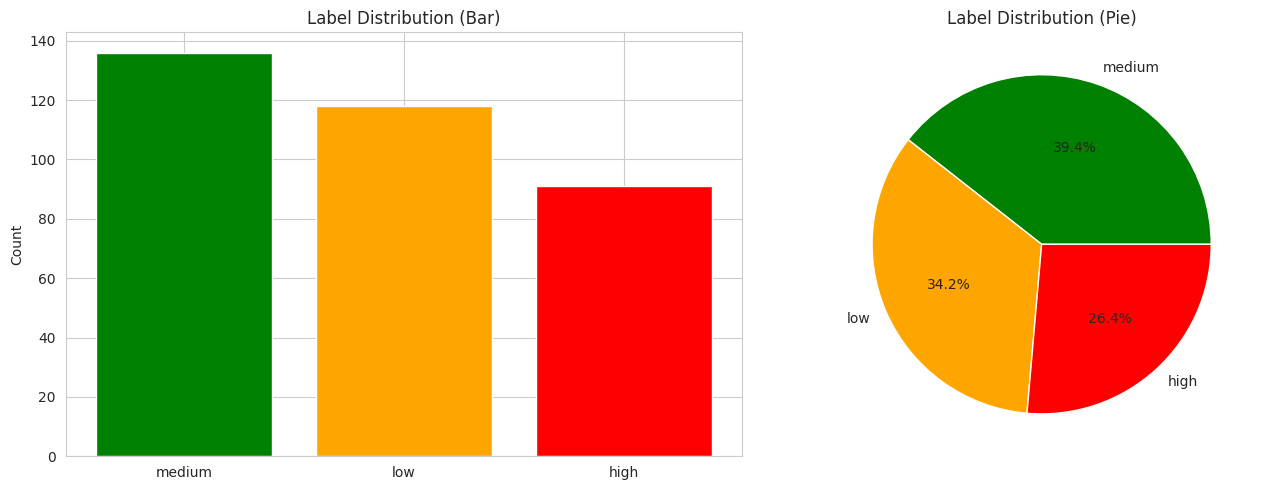

In [20]:
# Pie chart + bar side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['match_label'].str.lower().value_counts()

axes[0].bar(counts.index, counts.values, color=['green','orange','red'])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['green','orange','red'])
axes[1].set_title('Label Distribution (Pie)')

plt.tight_layout()
plt.show()

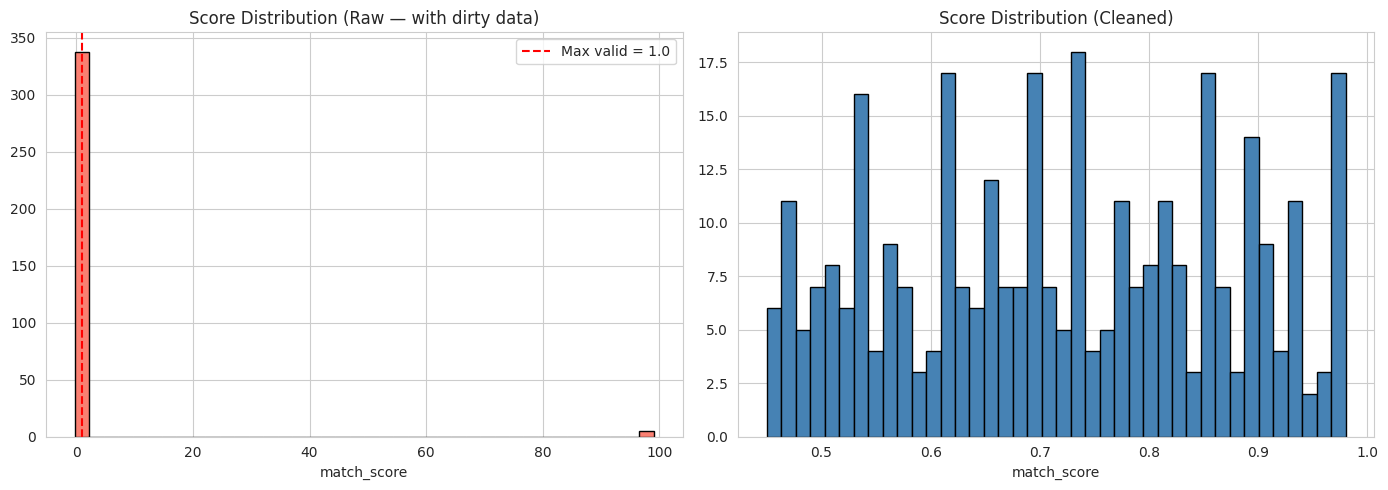

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
axes[0].hist(df['match_score'], bins=40, color='salmon', edgecolor='black')
axes[0].set_title('Score Distribution (Raw — with dirty data)')
axes[0].set_xlabel('match_score')
axes[0].axvline(1.0, color='red', linestyle='--', label='Max valid = 1.0')
axes[0].legend()

# After cleaning
clean = df[(df['match_score'] >= 0) & (df['match_score'] <= 1)]
axes[1].hist(clean['match_score'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Score Distribution (Cleaned)')
axes[1].set_xlabel('match_score')

plt.tight_layout()
plt.show()

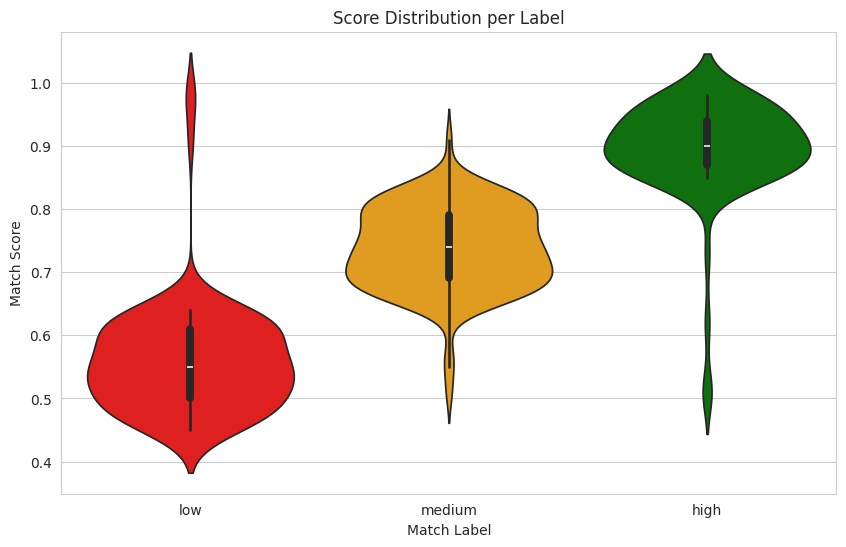

In [22]:
import seaborn as sns

df_plot = df.copy()
df_plot['match_label'] = df_plot['match_label'].str.lower()
df_plot = df_plot[(df_plot['match_score'] >= 0) & (df_plot['match_score'] <= 1)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_plot, x='match_label', y='match_score',
               order=['low','medium','high'],
               palette=['red','orange','green'])
plt.title('Score Distribution per Label')
plt.xlabel('Match Label')
plt.ylabel('Match Score')
plt.show()

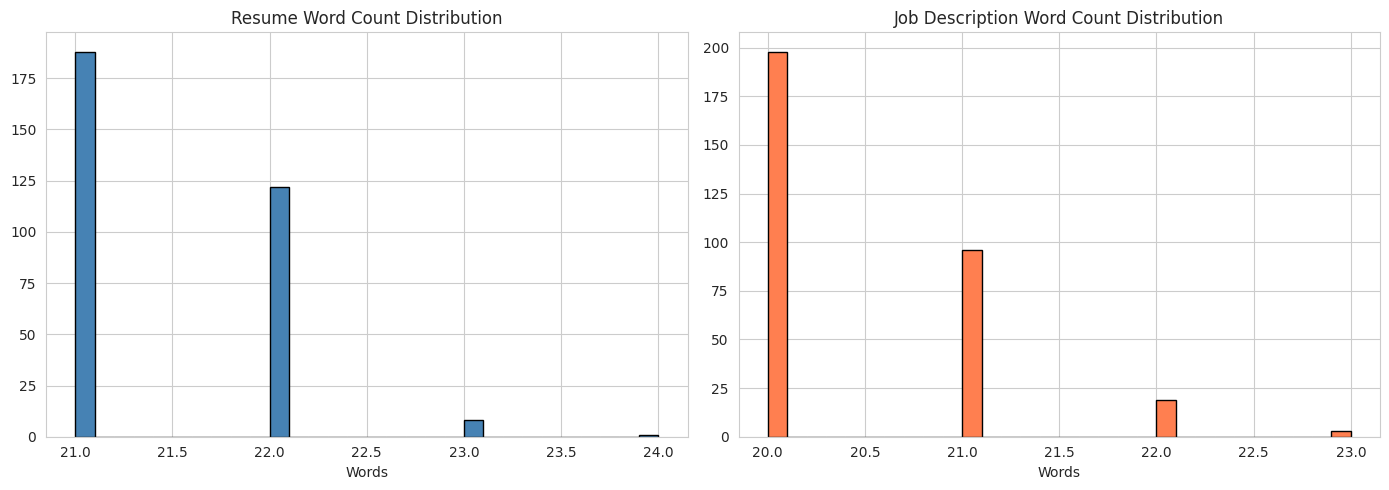

In [23]:
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len']     = df_plot['job_description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Job Description Word Count Distribution')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

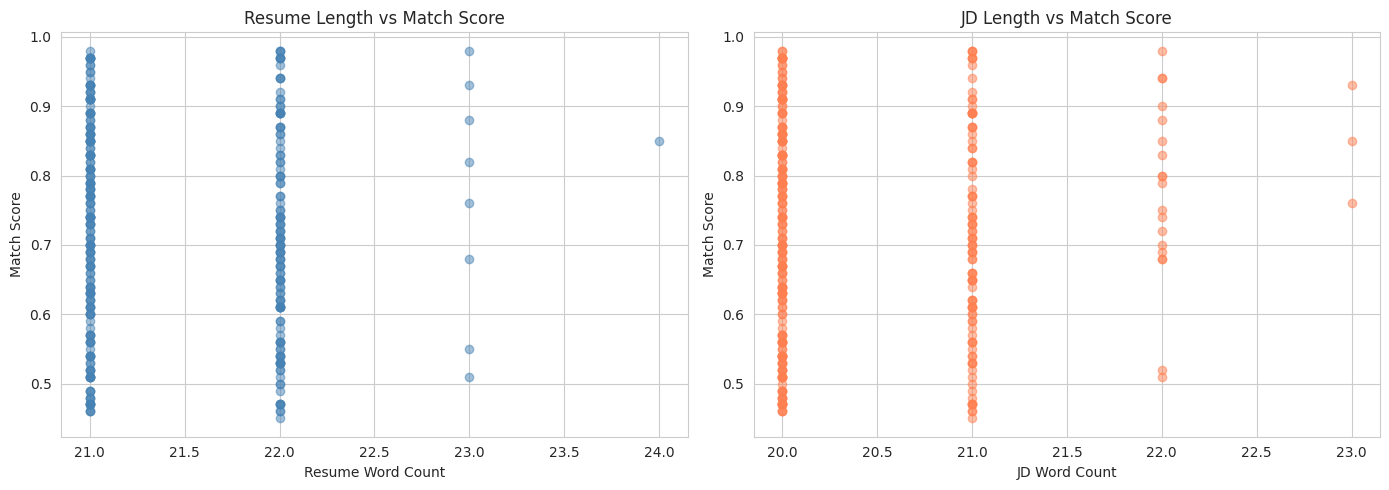

Resume length correlation: -0.025
JD length correlation:     0.06


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

plt.tight_layout()
plt.show()

# Actual correlation values
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))
print("JD length correlation:    ", df_plot['jd_len'].corr(df_plot['match_score']).round(3))

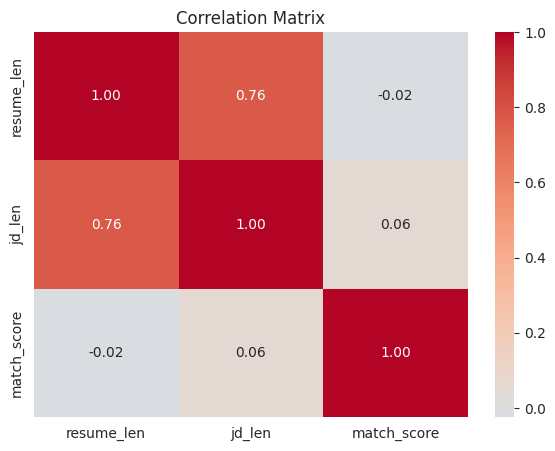

In [25]:
plt.figure(figsize=(7, 5))
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()


In [26]:
pip install wordcloud


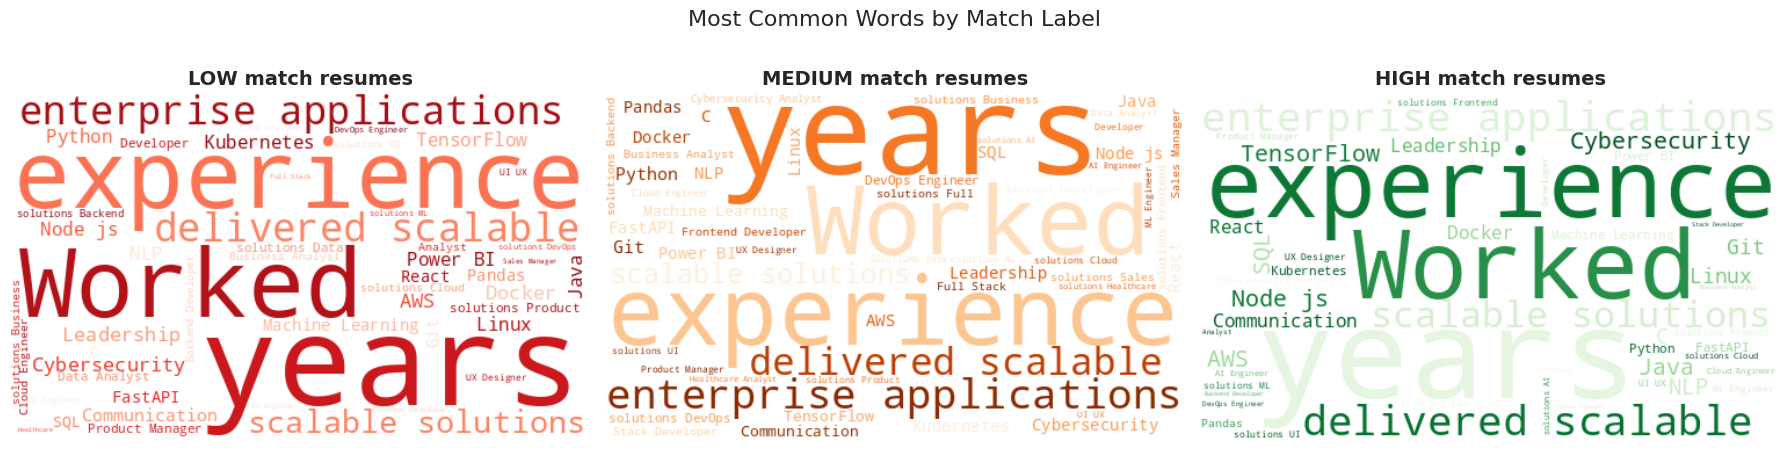

In [27]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels  = ['low', 'medium', 'high']
colors  = ['Reds', 'Oranges', 'Greens']

for ax, label, cmap in zip(axes, labels, colors):
    text = ' '.join(df_plot[df_plot['match_label'] == label]['resume_text'].dropna())
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label.upper()} match resumes', fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Match Label', fontsize=16)
plt.tight_layout()
plt.show()

In [28]:
# Always record the starting point so that you  can see what changed
print("BEFORE CLEANING")
print("=" * 40)
print(f"Total rows:       {len(df)}")
print(f"Null resume_text: {df['resume_text'].isnull().sum()}")
print(f"Null job_desc:    {df['job_description'].isnull().sum()}")
print(f"Duplicates:       {df.duplicated().sum()}")
print(f"Label variants:   {df['match_label'].nunique()}")
print(f"Invalid scores:   {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")

df_clean = df.copy()

BEFORE CLEANING
Total rows:       345
Null resume_text: 15
Null job_desc:    18
Duplicates:       18
Label variants:   3
Invalid scores:   10


In [29]:
# Problem: 'high', 'High', 'HIGH' are treated as 3 different categories
print("Before:", df_clean['match_label'].value_counts().to_dict())

df_clean['match_label'] = df_clean['match_label'].str.lower().str.strip()

print("After: ", df_clean['match_label'].value_counts().to_dict())
print(f"\nUnique labels now: {df_clean['match_label'].nunique()} (expected 3)")

Before: {'medium': 136, 'low': 118, 'high': 91}
After:  {'medium': 136, 'low': 118, 'high': 91}

Unique labels now: 3 (expected 3)


In [30]:
print(f"Before dropping nulls: {len(df_clean)} rows")

df_clean = df_clean.dropna(subset=['resume_text', 'job_description'])

print(f"After dropping nulls:  {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")

Before dropping nulls: 345 rows
After dropping nulls:  313 rows
Removed: 32 rows


In [31]:
print(f"Before removing duplicates: {len(df_clean)} rows")
print(f"Duplicate pairs found: {df_clean.duplicated(subset=['resume_text','job_description']).sum()}")

df_clean = df_clean.drop_duplicates(subset=['resume_text', 'job_description'], keep='first')

print(f"After removing duplicates:  {len(df_clean)} rows")

Before removing duplicates: 313 rows
Duplicate pairs found: 16
After removing duplicates:  297 rows


In [32]:
# Scores must be in [0.0, 1.0], anything else is a data error
invalid_mask = (df_clean['match_score'] < 0.0) | (df_clean['match_score'] > 1.0)
print(f"Invalid scores found: {invalid_mask.sum()}")
print(df_clean[invalid_mask][['match_label','match_score']])

df_clean = df_clean[~invalid_mask]
print(f"\nRows after removing invalid scores: {len(df_clean)}")

Invalid scores found: 9
    match_label  match_score
17         high         99.0
19          low         99.0
93         high         99.0
102        high         -0.2
105      medium         99.0
141      medium         -0.2
157         low          1.2
303         low          1.2
306      medium          1.2

Rows after removing invalid scores: 288


In [33]:
#are the scores consistent with what the label claims?
# Expected: low=0.05-0.35, medium=0.40-0.70, high=0.75-0.95

print("Score range per label:")
print(df_clean.groupby('match_label')['match_score'].agg(['min','max','mean']).round(2))

# Flag any rows where label and score contradict each other
def label_score_mismatch(row):
    score = row['match_score']
    label = row['match_label']
    if label == 'high'   and score < 0.70: return True
    if label == 'medium' and (score < 0.35 or score > 0.75): return True
    if label == 'low'    and score > 0.40: return True
    return False

mismatches = df_clean.apply(label_score_mismatch, axis=1)
print(f"\nLabel-score mismatches: {mismatches.sum()}")
df_clean[mismatches][['match_label','match_score']]

Score range per label:
              min   max  mean
match_label                  
high         0.51  0.98  0.90
low          0.45  0.98  0.56
medium       0.51  0.91  0.74

Label-score mismatches: 150


,match_label,match_score
5,medium,0.80
7,medium,0.79
9,low,0.46
11,low,0.49
13,medium,0.79
...,...,...
317,low,0.51
318,medium,0.81
319,low,0.53
332,low,0.56


In [34]:
# A 15-character resume or JD is useless for training
df_clean['resume_len'] = df_clean['resume_text'].str.split().str.len()
df_clean['jd_len']     = df_clean['job_description'].str.split().str.len()

print("Short texts found:")
print(f"  resume_text < 20 words: {(df_clean['resume_len'] < 20).sum()}")
print(f"  job_description < 10 words: {(df_clean['jd_len'] < 10).sum()}")

df_clean = df_clean[(df_clean['resume_len'] >= 20) & (df_clean['jd_len'] >= 10)]
print(f"\nRows after removing short texts: {len(df_clean)}")

Short texts found:
  resume_text < 20 words: 0
  job_description < 10 words: 0

Rows after removing short texts: 288


In [35]:
df_clean = df_clean.reset_index(drop=True)

print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)
print(f"  Original rows:        {len(df)}")
print(f"  Final rows:           {len(df_clean)}")
print(f"  Rows removed:         {len(df) - len(df_clean)}")
print()
print(f"  Nulls remaining:      {df_clean.isnull().sum().sum()}")
print(f"  Duplicates remaining: {df_clean.duplicated().sum()}")
print(f"  Label variants:       {df_clean['match_label'].nunique()}")
print(f"  Score range:          {df_clean['match_score'].min()} – {df_clean['match_score'].max()}")
print()
print("Label distribution after cleaning:")
print(df_clean['match_label'].value_counts())
print("=" * 45)

CLEANING SUMMARY
  Original rows:        345
  Final rows:           288
  Rows removed:         57

  Nulls remaining:      0
  Duplicates remaining: 0
  Label variants:       3
  Score range:          0.45 – 0.98

Label distribution after cleaning:
match_label
medium    118
low        97
high       73
Name: count, dtype: int64


In [37]:
# Drop the helper columns we added during EDA
df_clean.to_csv('clear_resumeJD_pairs.csv', index=False)
print(f"Saved:clear_resumeJD_pairs.csv ({len(df_clean)} rows)")

Saved:clear_resumeJD_pairs.csv (288 rows)
